MNIST dataset contains 28x28 hand-written digits. Please extract 5x5 patches from 28x28 images, and there are more than 20 million such image patches. Of course, a majority of these image patches will be blank. You can discard these blank patches and focus on the rest ones, and do a K-mean clustering with these small image patches.

Please analyze the change of the learned clusters when you increase K from 100 – 10,000 (or even more). You can also analyze how well you can reconstruct a 5x5 MNIST patch by your learned dictionary (clusters). There are some interesting questions: 1) How many clusters do you need in order to cover the whole patch space? What are these clusters and do they have any interpretable meanings? How is one digit made from these clusters? These questions are just some example questions, and you are in charge of what is interesting to you in this weird image patch space.

One useful trick in this experiment may be that you can normalize your patch vector to unit norm, then your clusters can also be normalized, and the Euclidean distance is equivalent to sqrt(2-2<feature vector, image patch vector>). Of course, this will create issue with all blank patch, which needs additional care.



In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.preprocessing import normalize
from sklearn.cluster import MiniBatchKMeans


In [6]:
dataset = torchvision.datasets.MNIST(
    root='./data',         
    download=True
)

In [7]:
def patchify(imgs: torch.Tensor, patch=5, stride=1):
    #input: (B, C, H, W)
    cols = F.unfold(imgs, kernel_size=patch, stride=stride).transpose(1, 2)
    # out: (B, L, 25)  L = number of patches per image
    # Merge (B, L)
    patches = cols.reshape(-1, 25)
    return patches

In [51]:
images = dataset.data.float() / 255.0
images = images.unsqueeze(1)
patches=patchify(images)

#keep only images with non-zero values
non_blank = patches[patches.sum(dim=1) > 0]
print("before norm: ",non_blank[0])
print(non_blank.shape)
patch_vectors = normalize(non_blank, norm='l2')
print("after norm: ", patch_vectors[0])
print(patch_vectors.shape)

before norm:  tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118])
torch.Size([20074704, 25])
after norm:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1.]
(20074704, 25)


In [22]:
from joblib import dump
from sklearn.cluster import MiniBatchKMeans

for K in [100, 1000, 10000]:
    kmeans = MiniBatchKMeans(
        n_clusters=K,
        random_state=0,
        batch_size=16384,
        max_iter=100,
        n_init="auto",
    ).fit(patch_vectors)

    dump(kmeans, f"kmeans_K{K}.pkl")

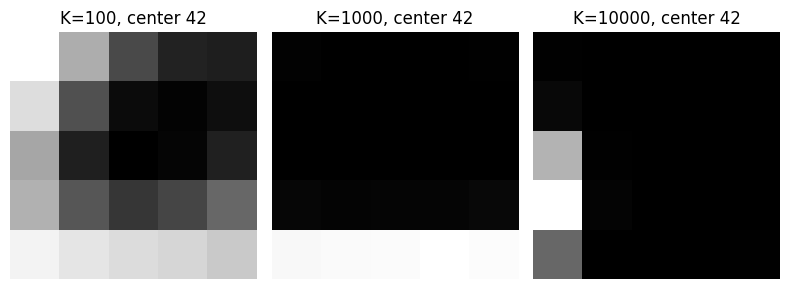

In [29]:
from joblib import load
import numpy as np
import matplotlib.pyplot as plt

Ks = [100, 1000, 10000]
j = 42 
fig, axs = plt.subplots(1, 3, figsize=(8, 3))

for ax, K in zip(axs, Ks):
    kmeans = load(f"kmeans_K{K}.pkl")
    centers = kmeans.cluster_centers_
    centers_5x5 = centers.reshape(-1, 5, 5)
    n_centers = centers_5x5.shape[0]
    ax.imshow(centers_5x5[j], cmap="gray")
    ax.axis("off")
    ax.set_title(f"K={K}, center {j}")

plt.tight_layout()
plt.show()


torch.Size([60000, 1, 28, 28])
(28, 28)


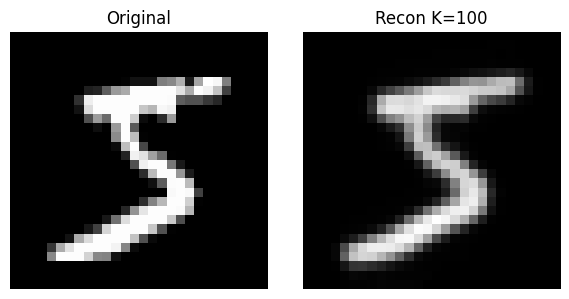

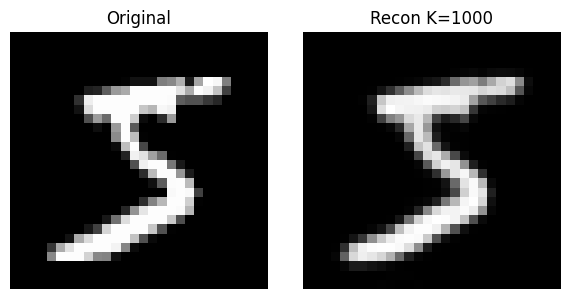

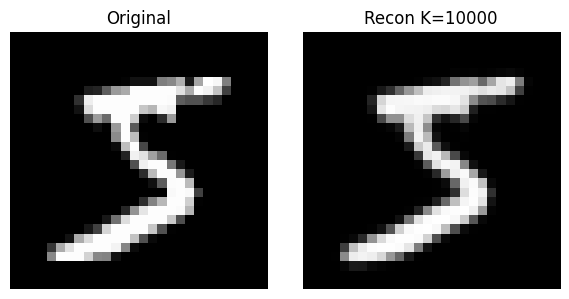

In [104]:
from joblib import load
import numpy as np
import matplotlib.pyplot as plt

print(images.shape)
img28 = images[0].squeeze().numpy().astype(np.float32)
print(img28.shape)

for K in [100, 1000, 10000]:
    kmeans = load(f"kmeans_K{K}.pkl")

    #extract patches
    X = []
    coords = []
    for r in range(24):
        for c in range(24):
            X.append(img28[r:r+5, c:c+5].reshape(-1))
            coords.append((r, c))
    X = np.stack(X, axis=0)                 

    # L2 normalize
    norms = np.linalg.norm(X, axis=1)
    keep = norms > 0
    Xn = np.zeros_like(X, dtype=np.float32)
    Xn[keep] = X[keep] / norms[keep, None]
    Xn = Xn.astype(kmeans.cluster_centers_.dtype, copy=False)
    labels_keep = kmeans.predict(Xn[keep])
    centers = kmeans.cluster_centers_.astype(np.float32, copy=False)
    Xhat_all = np.zeros((X.shape[0], 25), dtype=np.float32)
    Xhat_all[keep] = centers[labels_keep]

    #un-normalize for visualization
    Xhat_all *= norms[:, None].astype(np.float32)

    acc = np.zeros((28, 28), dtype=np.float32)
    cnt = np.zeros((28, 28), dtype=np.float32)
    for patch, (r, c) in zip(Xhat_all.reshape(-1, 5, 5), coords):
        acc[r:r+5, c:c+5] += patch
        cnt[r:r+5, c:c+5] += 1.0
    #normalize by # overlapping patches
    recon28 = acc / np.maximum(cnt, 1e-8)

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(img28, cmap="gray")
    plt.axis("off")
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(recon28, cmap="gray")
    plt.axis("off")
    plt.title(f"Recon K={K}")
    plt.tight_layout()
    plt.show()
